# EfficientNet-B4 — Confusion Matrix (200개) · **로컬 노트북**

GPU / S3 없이 **PC에서 이 노트북만** 실행합니다.

## 준비
1. Downloads에 EfficientNet-B4 JSON 2개
2. 터미널: `pip install matplotlib seaborn scikit-learn numpy`
3. Cursor에서 이 `.ipynb` 열기 → **Run All**

| 파일 | model | profile |
|------|-------|---------|
| `infer_summary (1).json` | efficientnetb4 | ffpp_vox |
| `infer_summary.json` | efficientnetb4 | celebdf |

경로가 다르면 **셀 2**의 `LOCAL_FILES`만 수정하세요.

팀 CM 표기: [09-CNN-벤치마크-Confusion-Matrix-ROC.md](../09-CNN-벤치마크-Confusion-Matrix-ROC.md) 부록


In [6]:
# 첫 실행 시 주석 해제:
# !pip install matplotlib seaborn scikit-learn numpy

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib as mpl
import matplotlib.font_manager as fm


def _setup_korean_font() -> str:
    """CM 축 라벨(가짜/진짜) 한글이 □로 깨지지 않게 폰트 설정."""
    candidates = [
        "Malgun Gothic",
        "NanumGothic",
        "Nanum Gothic",
        "AppleGothic",
        "Noto Sans CJK KR",
        "Noto Sans KR",
    ]
    available = {f.name for f in fm.fontManager.ttflist}
    for name in candidates:
        if name in available:
            mpl.rcParams["font.family"] = name
            mpl.rcParams["axes.unicode_minus"] = False
            return name
    mpl.rcParams["axes.unicode_minus"] = False
    return "default (Korean font not found — install Malgun Gothic or NanumGothic)"


_kr_font = _setup_korean_font()
print(f"matplotlib font: {_kr_font}")

NOTEBOOK_DIR = Path(r"c:\FINAL\docs\ai\notebooks")

LOCAL_FILES = {
    "ffpp_vox": Path(r"c:\Users\user\Downloads\infer_summary (1).json"),
    "celebdf": Path(r"c:\Users\user\Downloads\infer_summary.json"),
}

OUT_DIR = NOTEBOOK_DIR / "output" / "efficientnetb4-cm"
OUT_DIR.mkdir(parents=True, exist_ok=True)

LABELS_TEAM = ["fake", "real"]

for k, p in LOCAL_FILES.items():
    if not p.is_file():
        raise FileNotFoundError(f"{k}: file not found -> {p}")
print("OK: both JSON files found")


matplotlib font: Malgun Gothic
OK: both JSON files found


In [7]:
def load_items(path: Path) -> list[dict]:
    data = json.loads(path.read_text(encoding="utf-8"))
    assert data["model"] == "efficientnetb4", f"expected efficientnetb4, got {data.get('model')} in {path.name}"
    print(f"{data['model']} / {data['profile']} / n={data['count']}  ({path.name})")
    return data["items"]


items_ffpp = load_items(LOCAL_FILES["ffpp_vox"])
items_celeb = load_items(LOCAL_FILES["celebdf"])
items_all = items_ffpp + items_celeb

print(f"total: {len(items_all)}")

y_true = [it["ground_truth_label"] for it in items_all]
y_pred = [it["pred_label"] for it in items_all]


efficientnetb4 / ffpp_vox / n=100  (infer_summary (1).json)
efficientnetb4 / celebdf / n=100  (infer_summary.json)
total: 200


saved c:\FINAL\docs\ai\notebooks\output\efficientnetb4-cm\cm_efficientnetb4_200_combined.png


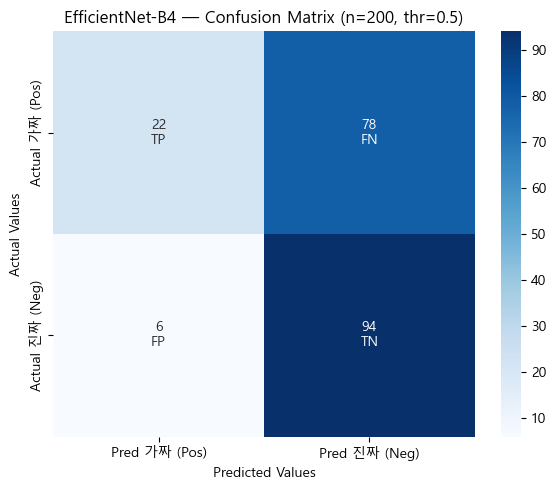

CM (rows=fake,real):
 [[22 78]
 [ 6 94]]
              precision    recall  f1-score   support

        fake      0.786     0.220     0.344       100
        real      0.547     0.940     0.691       100

    accuracy                          0.580       200
   macro avg      0.666     0.580     0.517       200
weighted avg      0.666     0.580     0.517       200



In [8]:
def plot_team_cm(y_true, y_pred, title: str, out_path: Path | None = None):
    cm = confusion_matrix(y_true, y_pred, labels=LABELS_TEAM)
    tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

    annot = np.array([[f"{tp}\nTP", f"{fn}\nFN"], [f"{fp}\nFP", f"{tn}\nTN"]])

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=True,
        xticklabels=["Pred 가짜 (Pos)", "Pred 진짜 (Neg)"],
        yticklabels=["Actual 가짜 (Pos)", "Actual 진짜 (Neg)"],
        ax=ax,
    )
    ax.set_xlabel("Predicted Values")
    ax.set_ylabel("Actual Values")
    ax.set_title(title)
    fig.tight_layout()
    if out_path:
        fig.savefig(out_path, dpi=150, bbox_inches="tight")
        print(f"saved {out_path}")
    plt.show()
    return cm


cm200 = plot_team_cm(
    y_true,
    y_pred,
    title=f"EfficientNet-B4 — Confusion Matrix (n={len(items_all)}, thr=0.5)",
    out_path=OUT_DIR / "cm_efficientnetb4_200_combined.png",
)
print("CM (rows=fake,real):\n", cm200)
print(classification_report(y_true, y_pred, labels=LABELS_TEAM, digits=3))


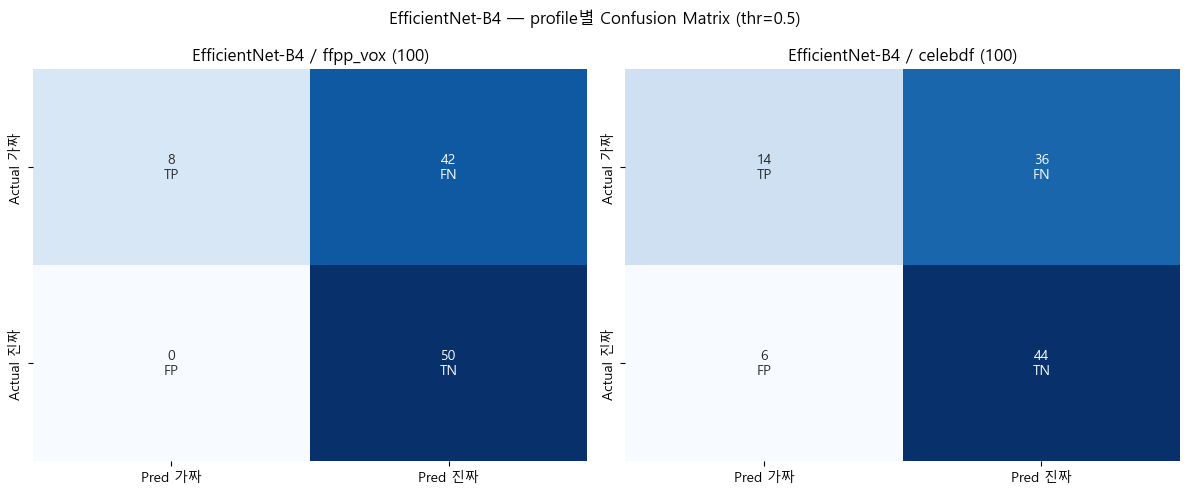

saved c:\FINAL\docs\ai\notebooks\output\efficientnetb4-cm\cm_efficientnetb4_200_by_profile.png


In [9]:
# (선택) 프로필별 2장 — ffpp_vox vs celebdf 비교용
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, name, items in [
    (axes[0], "ffpp_vox (100)", items_ffpp),
    (axes[1], "celebdf (100)", items_celeb),
]:
    yt = [it["ground_truth_label"] for it in items]
    yp = [it["pred_label"] for it in items]
    cm = confusion_matrix(yt, yp, labels=LABELS_TEAM)
    annot = np.array(
        [[f"{cm[0,0]}\nTP", f"{cm[0,1]}\nFN"], [f"{cm[1,0]}\nFP", f"{cm[1,1]}\nTN"]]
    )
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        xticklabels=["Pred 가짜", "Pred 진짜"],
        yticklabels=["Actual 가짜", "Actual 진짜"],
        ax=ax,
        cbar=False,
    )
    ax.set_title(f"EfficientNet-B4 / {name}")
fig.suptitle("EfficientNet-B4 — profile별 Confusion Matrix (thr=0.5)")
fig.tight_layout()
split_path = OUT_DIR / "cm_efficientnetb4_200_by_profile.png"
fig.savefig(split_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"saved {split_path}")


## 분류 지표 추출 (Accuracy · Precision · Recall · F1)

Confusion Matrix에서 TP/FN/FP/TN을 읽어 [부록 B](../09-CNN-벤치마크-Confusion-Matrix-ROC.md#부록-b--accuracy--precision--recall--f1-score) 공식으로 계산합니다.

**Positive = 가짜(`fake`)** 기준:

| 지표 | 공식 |
|------|------|
| Accuracy(정확도) | (TP + TN) / (TP + FN + FP + TN) |
| Precision(정밀도) | TP / (TP + FP) |
| Recall(재현도) | TP / (TP + FN) |
| F1-Score(조화평균) | 2 × Precision(정밀도) × Recall(재현도) / (Precision(정밀도) + Recall(재현도)) |


In [10]:
import pandas as pd
from IPython.display import Markdown, display


def metrics_from_cm(cm: np.ndarray) -> dict:
    tp, fn, fp, tn = int(cm[0, 0]), int(cm[0, 1]), int(cm[1, 0]), int(cm[1, 1])
    total = tp + fn + fp + tn
    accuracy = (tp + tn) / total
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
    return {
        "TP": tp, "FN": fn, "FP": fp, "TN": tn, "n": total,
        "accuracy": accuracy, "precision": precision, "recall": recall, "f1": f1,
        "acc_num": tp + tn,
        "acc_den": total,
        "prec_num": tp,
        "prec_den": tp + fp,
        "rec_num": tp,
        "rec_den": tp + fn,
        "f1_num": 2 * tp,
        "f1_den": 2 * tp + fp + fn,
    }


def metrics_table(m: dict) -> pd.DataFrame:
    """지표별 분자·분모·값 표."""
    rows = [
        {
            "지표": "Accuracy(정확도)",
            "분자": f"TP + TN = {m['TP']} + {m['TN']} = {m['acc_num']}",
            "분모": f"TP + FN + FP + TN = {m['n']}",
            "수식": f"{m['acc_num']} / {m['acc_den']}",
            "값": f"{m['accuracy']:.4f}",
            "백분율": f"{m['accuracy'] * 100:.2f}%",
        },
        {
            "지표": "Precision(정밀도)",
            "분자": f"TP = {m['prec_num']}",
            "분모": f"TP + FP = {m['TP']} + {m['FP']} = {m['prec_den']}",
            "수식": f"{m['prec_num']} / {m['prec_den']}",
            "값": f"{m['precision']:.4f}",
            "백분율": f"{m['precision'] * 100:.2f}%",
        },
        {
            "지표": "Recall(재현도)",
            "분자": f"TP = {m['rec_num']}",
            "분모": f"TP + FN = {m['TP']} + {m['FN']} = {m['rec_den']}",
            "수식": f"{m['rec_num']} / {m['rec_den']}",
            "값": f"{m['recall']:.4f}",
            "백분율": f"{m['recall'] * 100:.2f}%",
        },
        {
            "지표": "F1-Score(조화평균)",
            "분자": f"2 × TP = 2 × {m['TP']} = {m['f1_num']}",
            "분모": f"2×TP + FP + FN = {m['f1_den']}",
            "수식": f"{m['f1_num']} / {m['f1_den']}",
            "값": f"{m['f1']:.4f}",
            "백분율": f"{m['f1'] * 100:.2f}%",
        },
    ]
    return pd.DataFrame(rows)


def display_metrics_block(label: str, yt, yp) -> dict:
    cm = confusion_matrix(yt, yp, labels=LABELS_TEAM)
    m = metrics_from_cm(cm)
    tp, fn, fp, tn = m["TP"], m["FN"], m["FP"], m["TN"]

    display(Markdown(f"### {label}  \n**n = {m['n']}** · Positive = fake (가짜)"))

    display(Markdown(
        f"""
| | Pred fake | Pred real |
|---|---:|---:|
| **Actual fake** | **TP = {tp}** | FN = {fn} |
| **Actual real** | FP = {fp} | **TN = {tn}** |
"""
    ))

    display(metrics_table(m))

    p, r = m["precision"], m["recall"]
    display(Markdown(
        f"""
**LaTeX 형태**

$$
\\text{{Accuracy(정확도)}} = \\frac{{TP + TN}}{{TP + FN + FP + TN}}
= \\frac{{{tp} + {tn}}}{{{m['n']}}}
= \\frac{{{m['acc_num']}}}{{{m['acc_den']}}}
= {m['accuracy']:.4f}
$$

$$
\\text{{Precision(정밀도)}} = \\frac{{TP}}{{TP + FP}}
= \\frac{{{tp}}}{{{tp} + {fp}}}
= \\frac{{{m['prec_num']}}}{{{m['prec_den']}}}
= {m['precision']:.4f}
$$

$$
\\text{{Recall(재현도)}} = \\frac{{TP}}{{TP + FN}}
= \\frac{{{tp}}}{{{tp} + {fn}}}
= \\frac{{{m['rec_num']}}}{{{m['rec_den']}}}
= {m['recall']:.4f}
$$

$$
\text{{F1-Score(조화평균)}} = \\frac{{2 \\times \\text{{Precision(정밀도)}} \\times \\text{{Recall(재현도)}}}}{{\\text{{Precision(정밀도)}} + \\text{{Recall(재현도)}}}}
= \\frac{{2 \\times TP}}{{2 \\times TP + FP + FN}}
= \\frac{{{m['f1_num']}}}{{{m['f1_den']}}}
= {m['f1']:.4f}
$$
"""
    ))
    return m


yt_ffpp = [it["ground_truth_label"] for it in items_ffpp]
yp_ffpp = [it["pred_label"] for it in items_ffpp]
yt_celeb = [it["ground_truth_label"] for it in items_celeb]
yp_celeb = [it["pred_label"] for it in items_celeb]

m_all = display_metrics_block("EfficientNet-B4 200 (ffpp_vox + celebdf)", y_true, y_pred)
m_ffpp = display_metrics_block("EfficientNet-B4 · ffpp_vox", yt_ffpp, yp_ffpp)
m_celeb = display_metrics_block("EfficientNet-B4 · celebdf", yt_celeb, yp_celeb)

summary = pd.DataFrame([
    {
        "구분": "200 combined",
        "TP": m_all["TP"], "FN": m_all["FN"], "FP": m_all["FP"], "TN": m_all["TN"],
        "Accuracy(정확도)": f"{m_all['acc_num']}/{m_all['acc_den']} = {m_all['accuracy']:.3f}",
        "Precision(정밀도)": f"{m_all['prec_num']}/{m_all['prec_den']} = {m_all['precision']:.3f}",
        "Recall(재현도)": f"{m_all['rec_num']}/{m_all['rec_den']} = {m_all['recall']:.3f}",
        "F1-Score(조화평균)": f"{m_all['f1_num']}/{m_all['f1_den']} = {m_all['f1']:.3f}",
    },
    {
        "구분": "ffpp_vox",
        "TP": m_ffpp["TP"], "FN": m_ffpp["FN"], "FP": m_ffpp["FP"], "TN": m_ffpp["TN"],
        "Accuracy(정확도)": f"{m_ffpp['acc_num']}/{m_ffpp['acc_den']} = {m_ffpp['accuracy']:.3f}",
        "Precision(정밀도)": f"{m_ffpp['prec_num']}/{m_ffpp['prec_den']} = {m_ffpp['precision']:.3f}",
        "Recall(재현도)": f"{m_ffpp['rec_num']}/{m_ffpp['rec_den']} = {m_ffpp['recall']:.3f}",
        "F1-Score(조화평균)": f"{m_ffpp['f1_num']}/{m_ffpp['f1_den']} = {m_ffpp['f1']:.3f}",
    },
    {
        "구분": "celebdf",
        "TP": m_celeb["TP"], "FN": m_celeb["FN"], "FP": m_celeb["FP"], "TN": m_celeb["TN"],
        "Accuracy(정확도)": f"{m_celeb['acc_num']}/{m_celeb['acc_den']} = {m_celeb['accuracy']:.3f}",
        "Precision(정밀도)": f"{m_celeb['prec_num']}/{m_celeb['prec_den']} = {m_celeb['precision']:.3f}",
        "Recall(재현도)": f"{m_celeb['rec_num']}/{m_celeb['rec_den']} = {m_celeb['recall']:.3f}",
        "F1-Score(조화평균)": f"{m_celeb['f1_num']}/{m_celeb['f1_den']} = {m_celeb['f1']:.3f}",
    },
])

display(Markdown("### 전체 요약"))
display(summary)


### EfficientNet-B4 200 (ffpp_vox + celebdf)  
**n = 200** · Positive = fake (가짜)


| | Pred fake | Pred real |
|---|---:|---:|
| **Actual fake** | **TP = 22** | FN = 78 |
| **Actual real** | FP = 6 | **TN = 94** |


,지표,분자,분모,수식,값,백분율
0,Accuracy(정확도),TP + TN = 22 + 94 = 116,TP + FN + FP + TN = 200,116 / 200,0.5800,58.00%
1,Precision(정밀도),TP = 22,TP + FP = 22 + 6 = 28,22 / 28,0.7857,78.57%
2,Recall(재현도),TP = 22,TP + FN = 22 + 78 = 100,22 / 100,0.2200,22.00%
3,F1-Score(조화평균),2 × TP = 2 × 22 = 44,2×TP + FP + FN = 128,44 / 128,0.3437,34.37%



**LaTeX 형태**

$$
\text{Accuracy(정확도)} = \frac{TP + TN}{TP + FN + FP + TN}
= \frac{22 + 94}{200}
= \frac{116}{200}
= 0.5800
$$

$$
\text{Precision(정밀도)} = \frac{TP}{TP + FP}
= \frac{22}{22 + 6}
= \frac{22}{28}
= 0.7857
$$

$$
\text{Recall(재현도)} = \frac{TP}{TP + FN}
= \frac{22}{22 + 78}
= \frac{22}{100}
= 0.2200
$$

$$
	ext{F1-Score(조화평균)} = \frac{2 \times \text{Precision(정밀도)} \times \text{Recall(재현도)}}{\text{Precision(정밀도)} + \text{Recall(재현도)}}
= \frac{2 \times TP}{2 \times TP + FP + FN}
= \frac{44}{128}
= 0.3437
$$


### EfficientNet-B4 · ffpp_vox  
**n = 100** · Positive = fake (가짜)

...


| | Pred fake | Pred real |
|---|---:|---:|
| **Actual fake** | **TP = 14** | FN = 36 |
| **Actual real** | FP = 6 | **TN = 44** |


,지표,분자,분모,수식,값,백분율
0,Accuracy(정확도),TP + TN = 14 + 44 = 58,TP + FN + FP + TN = 100,58 / 100,0.5800,58.00%
1,Precision(정밀도),TP = 14,TP + FP = 14 + 6 = 20,14 / 20,0.7000,70.00%
2,Recall(재현도),TP = 14,TP + FN = 14 + 36 = 50,14 / 50,0.2800,28.00%
3,F1-Score(조화평균),2 × TP = 2 × 14 = 28,2×TP + FP + FN = 70,28 / 70,0.4000,40.00%



**LaTeX 형태**

$$
\text{Accuracy(정확도)} = \frac{TP + TN}{TP + FN + FP + TN}
= \frac{14 + 44}{100}
= \frac{58}{100}
= 0.5800
$$

$$
\text{Precision(정밀도)} = \frac{TP}{TP + FP}
= \frac{14}{14 + 6}
= \frac{14}{20}
= 0.7000
$$

$$
\text{Recall(재현도)} = \frac{TP}{TP + FN}
= \frac{14}{14 + 36}
= \frac{14}{50}
= 0.2800
$$

$$
	ext{F1-Score(조화평균)} = \frac{2 \times \text{Precision(정밀도)} \times \text{Recall(재현도)}}{\text{Precision(정밀도)} + \text{Recall(재현도)}}
= \frac{2 \times TP}{2 \times TP + FP + FN}
= \frac{28}{70}
= 0.4000
$$


### 전체 요약

,구분,TP,FN,FP,TN,Accuracy(정확도),Precision(정밀도),Recall(재현도),F1-Score(조화평균)
0,200 combined,22,78,6,94,116/200 = 0.580,22/28 = 0.786,22/100 = 0.220,44/128 = 0.344
1,ffpp_vox,8,42,0,50,58/100 = 0.580,8/8 = 1.000,8/50 = 0.160,16/58 = 0.276
2,celebdf,14,36,6,44,58/100 = 0.580,14/20 = 0.700,14/50 = 0.280,28/70 = 0.400
